# Atividade de vendas no Brasil

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('vendas_brasil_1.csv')

## Entregável 1 NumPy

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  object 
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  object 
 3   canal_venda         37567 non-null  object 
 4   categoria           37617 non-null  object 
 5   produto             37617 non-null  object 
 6   vendedor            37577 non-null  object 
 7   fidelidade_cliente  37617 non-null  object 
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  praz

In [3]:
# Arrays
precos_unitarios = np.array(df['preco_unitario'])
custos_unitarios = np.array(df['custo_unitario'])
quantidades = np.array(df['quantidade'])
descontos = np.array(df['desconto_pct'])
receitas_totais = np.array(df['receita_total'])
fretes = np.array(df['frete'])
print(precos_unitarios)
print(custos_unitarios)
print(quantidades)
print(descontos)
print(receitas_totais)
print(fretes)

[ 739.39  187.48   76.11 ...   55.15  197.09 1057.41]
[561.75 135.15  61.4  ...  36.94 167.23 870.69]
[10  5 14 ...  7  7  4]
[ 5.2  0.6  0.7 ...  0.  10.9 10. ]
[6933.48  930.28 1058.5  ...  384.44 1960.18 3795.73]
[ 8.68   nan  7.98 ... 85.35 30.99 27.23]


In [4]:
# Novas infos
valor_bruto_venda = precos_unitarios * quantidades
valor_desconto = valor_bruto_venda * (descontos / 100)
custo_total = custos_unitarios * quantidades
lucro_estimado = valor_bruto_venda - valor_desconto - custo_total
print(valor_bruto_venda)
print(valor_desconto)
print(custo_total)
print(lucro_estimado)

[7393.9   937.4  1065.54 ...  386.05 1379.63 4229.64]
[384.4828    5.6244    7.45878 ...   0.      150.37967 422.964  ]
[5617.5   675.75  859.6  ...  258.58 1170.61 3482.76]
[1391.9172   256.0256   198.48122 ...  127.47      58.64033  323.916  ]


In [5]:
# Máscaras
receita_acima_da_media = receitas_totais > receitas_totais.mean()
venda_com_prejuízo = lucro_estimado < 0
venda_com_desconto_alto = descontos > descontos.mean()
print(receita_acima_da_media)
print(venda_com_prejuízo)
print(venda_com_desconto_alto)

[ True False False ... False  True  True]
[False False False ... False False False]
[False False False ... False  True  True]


In [6]:
# Agregações
receita_media = receitas_totais.mean()
maior_receita = receitas_totais.max()
menor_receita = receitas_totais.min()
lucro_medio = lucro_estimado.mean()
vendas_com_prejuízo_qtd = venda_com_prejuízo.sum()
print(receita_media)
print(maior_receita)
print(menor_receita)
print(lucro_medio)
print(vendas_com_prejuízo_qtd)

1891.6881729005502
58430.28
3.7
342.0324771624531
2857


### Análise baseada nas agregações

Podemos ver que houveram receitas expressivamnte maiores do que a média e que, apesar de apenas 2857 vendas com prejuízo, o lucro médio ainda foi cerca de 1/6 da receita média, o que pode rpresentar um custo alto de produção.

## Entregável 2 Pandas

### Primeiro olhar no dataset

In [7]:
df.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  object 
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  object 
 3   canal_venda         37567 non-null  object 
 4   categoria           37617 non-null  object 
 5   produto             37617 non-null  object 
 6   vendedor            37577 non-null  object 
 7   fidelidade_cliente  37617 non-null  object 
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  praz

In [9]:
df.describe()

,mes,preco_unitario,custo_unitario,margem_pct,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias
count,37617.000000,37617.000000,37617.000000,37535.000000,37617.000000,37617.000000,37617.000000,35738.000000,34662.000000,36113.000000
mean,6.517691,253.214933,183.620999,22.714776,7.481750,9.494048,1891.688173,29.885737,3.912094,10.017113
std,3.439296,316.742367,231.376757,8.670213,4.322273,9.097484,2972.445759,24.765161,0.932256,5.477487
min,1.000000,4.940000,3.010000,-0.570000,1.000000,0.000000,3.700000,3.750000,1.000000,1.000000
25%,4.000000,68.960000,49.550000,16.380000,4.000000,0.300000,364.280000,12.190000,3.490000,5.000000
50%,7.000000,111.300000,80.990000,22.700000,7.000000,9.000000,789.570000,22.250000,4.010000,10.000000
75%,9.000000,257.680000,186.570000,29.250000,11.000000,19.000000,1853.210000,39.480000,4.520000,15.000000
max,12.000000,9008.600000,6578.260000,44.270000,161.000000,26.000000,58430.280000,243.820000,5.000000,19.000000


In [10]:
df.shape

(37617, 21)

In [11]:
df.isna().sum()

,0
data_venda,0
mes,0
cidade,0
canal_venda,50
categoria,0
produto,0
vendedor,40
fidelidade_cliente,0
preco_unitario,0
custo_unitario,0


### Análise do dataset

São 37617 linhas e 21 colunas, podemos ver isso com "df.shape". Existem dados faltantes e "df.isna().sum()" mostra a quantidade deles em cada coluna do dataset. Segundo "df.info()" 10 colunas parecem numéricas (custo_unitario, preco_unitario e margem_pct, por exemplo) e 11 colunas parecem categoricas (cidade, devolucao e entrega_no_prazo, por exemplo).

### Limpeza e tratamento

In [12]:
df['data_venda'] = pd.to_datetime(df['data_venda'], format='mixed')
print(df['data_venda'])

0       2022-04-13
1       2023-03-12
2       2022-09-28
3       2022-04-17
4       2022-03-13
           ...    
37612   2023-12-31
37613   2023-12-31
37614   2023-12-31
37615   2023-12-31
37616   2023-12-31
Name: data_venda, Length: 37617, dtype: datetime64[ns]


In [13]:
# Analizar as colunas categoricas para procurar algo despadronizado
print(df.select_dtypes(include='object').columns)
for coluna in df.select_dtypes(include='object').columns:
    print(f"\nValores únicos para a coluna '{coluna}':")
    print(df[coluna].unique())

Index(['cidade', 'canal_venda', 'categoria', 'produto', 'vendedor',
       'fidelidade_cliente'],
      dtype='object')

Valores únicos para a coluna 'cidade':
['Rio de Janeiro' 'Manaus' 'Goiânia' 'Fortaleza' 'Belo Horizonte' 'Recife'
 'São Paulo' 'Porto Alegre' 'Salvador' 'Curitiba' 'salvador'
 'Belo Horizonte ' 'Rio de janeiro' 'Curtiba' 'Curitiba ' 'SP'
 ' Fortaleza' 'curitiba' 'RJ' 'S. Paulo' ' Salvador' 'Manaus ' 'São paulo'
 'Fortaleza ' 'Sao Paulo' 'BH' 'Rio de Janeiro ' ' Belo Horizonte'
 ' Recife' 'Slavador' 'Belo horizonte' 'Rio' ' Curitiba' ' Manaus'
 ' Goiânia' 'Recife ' 'B. Horizonte' 'Porto Alegre ' 'Rio De Janeiro'
 'São Paulo ' 'Goiânia ' ' Porto Alegre' 'Salvador ' ' Rio de Janeiro'
 ' São Paulo']

Valores únicos para a coluna 'canal_venda':
['App Mobile' 'Site Web' 'Loja Física' 'Marketplace' 'Televendas'
 'APP Mobile' 'site web' 'Site web' 'app mobile' 'SiteWeb' nan
 'Loja Fisica' 'App mobile' 'loja física' 'Loja fisica']

Valores únicos para a coluna 'categoria':
['

In [14]:
# Limpar espaços em branco e padronizar para Title Case
df['cidade'] = df['cidade'].str.strip().str.title()

# Tratar as variações da coluna cidade
correcao_cidades = {
    # São Paulo
    'Sao Paulo': 'São Paulo',
    'S. Paulo': 'São Paulo',
    'Sp': 'São Paulo',
    'São paulo': 'São Paulo',
    'São Paulo ': 'São Paulo',
    ' São Paulo': 'São Paulo',

    # Rio de Janeiro
    'Rj': 'Rio de Janeiro',
    'Rio': 'Rio de Janeiro',
    'Rio De Janeiro': 'Rio de Janeiro',
    'Rio de janeiro': 'Rio de Janeiro',
    'RJ': 'Rio de Janeiro',
    'Rio de Janeiro ': 'Rio de Janeiro',
    ' Rio de Janeiro': 'Rio de Janeiro',

    # Belo Horizonte
    'Bh': 'Belo Horizonte',
    'B. Horizonte': 'Belo Horizonte',
    'BH': 'Belo Horizonte',
    'Belo Horizonte ': 'Belo Horizonte',
    ' Belo Horizonte': 'Belo Horizonte',
    'Belo horizonte': 'Belo Horizonte',

    # Curitiba
    'Curtiba': 'Curitiba',
    'Curitiba ': 'Curitiba',
    'curitiba': 'Curitiba',
    ' Curitiba': 'Curitiba',

    # Salvador
    'Slavador': 'Salvador',
    'salvador': 'Salvador',
    ' Salvador': 'Salvador',
    'Salvador ': 'Salvador',

    # Goiânia
    ' Goiânia': 'Goiânia',
    'Goiânia ': 'Goiânia',

    # Manaus
    ' Manaus': 'Manaus',
    'Manaus ': 'Manaus',

    # Fortaleza
    ' Fortaleza': 'Fortaleza',
    'Fortaleza ': 'Fortaleza',

    # Recife
    ' Recife': 'Recife',
    'Recife ': 'Recife',

    # Porto Alegre
    'Porto Alegre ': 'Porto Alegre',
    ' Porto Alegre': 'Porto Alegre'
}

# Aplicar a correção
df['cidade'] = df['cidade'].replace(correcao_cidades)

# Verificar os valores únicos novamente para confirmar a limpeza
print("Valores únicos da coluna 'cidade' após a padronização:")
print(df['cidade'].unique())

Valores únicos da coluna 'cidade' após a padronização:
['Rio de Janeiro' 'Manaus' 'Goiânia' 'Fortaleza' 'Belo Horizonte' 'Recife'
 'São Paulo' 'Porto Alegre' 'Salvador' 'Curitiba']


In [15]:
# Escolhi preencher valores nulos na coluna 'frete' com a mediana por cidade
# para ter uma aproximação baseada na distância e mais robusta a outliers
# Agrupar por 'cidade' e aplicar a mediana do frete para preencher os NaNs
df['frete'] = df.groupby('cidade')['frete'].transform(lambda x: x.fillna(x.median()))

# Verificar se ainda há valores nulos na coluna 'frete'
print("Valores nulos na coluna 'frete' após o tratamento:")
print(df['frete'].isnull().sum())

Valores nulos na coluna 'frete' após o tratamento:
0


In [16]:
# Escolhi preencher os vazios na coluna 'canal_venda' com desconhecido por serem valores categóricos
df['canal_venda'] = df['canal_venda'].fillna('Desconhecido')

# Verificar se ainda há valores nulos na coluna 'canal_venda'
print("Valores nulos na coluna 'canal_venda' após o tratamento:")
print(df['canal_venda'].isnull().sum())

Valores nulos na coluna 'canal_venda' após o tratamento:
0


In [17]:
df.isna().sum()

,0
data_venda,0
mes,0
cidade,0
canal_venda,0
categoria,0
produto,0
vendedor,40
fidelidade_cliente,0
preco_unitario,0
custo_unitario,0


### Novas colunas

In [18]:
# Separar os anos de venda e o lucro
df['ano_venda'] = df['data_venda'].dt.year
df['lucro_total'] = lucro_estimado

# Categorizar a receita baseada na "receita_media" já calculada
df['faixa_receita'] = df['receita_total'].apply(lambda x: 'Baixa' if x < receita_media/2 else ('Média' if receita_media/2 <= x < 2*receita_media else 'Alta'))

print("DataFrame com as novas colunas:")
print(df[['data_venda', 'ano_venda', 'receita_total', 'lucro_total', 'faixa_receita']].head())
print("\nQuantidades de cada faixa de receita:")
print(df['faixa_receita'].value_counts())

DataFrame com as novas colunas:
  data_venda  ano_venda  receita_total  lucro_total faixa_receita
0 2022-04-13       2022        6933.48   1391.91720          Alta
1 2023-03-12       2023         930.28    256.02560         Baixa
2 2022-09-28       2022        1058.50    198.48122         Média
3 2022-04-17       2022        1592.43    621.00324         Média
4 2022-03-13       2022         107.64      0.55560         Baixa

Quantidades de cada faixa de receita:
faixa_receita
Baixa    21304
Média    11190
Alta      5123
Name: count, dtype: int64


### Agrupamentos

In [19]:
maior_receita_categoria = df.groupby('categoria')['receita_total'].sum().idxmax()
print(f"1. A categoria com maior receita total foi: {maior_receita_categoria}")

maior_quantidade_itens_canal = df.groupby('canal_venda')['quantidade'].sum().idxmax()
print(f"2a. O canal de venda com maior quantidade de itens vendidos foi: {maior_quantidade_itens_canal}")

maior_quantidade_vendas_canal = df['canal_venda'].value_counts().idxmax()
print(f"2b. O canal de venda com maior número de vendas (transações) foi: {maior_quantidade_vendas_canal}")

print("\nQuantidades de cada canal de venda:")
print(df['canal_venda'].value_counts())

maior_receita_cidade = df.groupby('cidade')['receita_total'].sum().idxmax()
print(f"\n3. A cidade com maior receita total foi: {maior_receita_cidade}")

1. A categoria com maior receita total foi: Eletrônicos
2a. O canal de venda com maior quantidade de itens vendidos foi: Site Web
2b. O canal de venda com maior número de vendas (transações) foi: Site Web

Quantidades de cada canal de venda:
canal_venda
Site Web        11267
App Mobile      11168
Loja Física      7445
Marketplace      5604
Televendas       1861
Desconhecido       50
app mobile         33
SiteWeb            31
APP Mobile         29
App mobile         28
site web           24
Site web           24
loja física        22
Loja Fisica        18
Loja fisica        13
Name: count, dtype: int64

3. A cidade com maior receita total foi: Recife


### Merge

In [20]:
# Tabela auxiliar
df_regioes = pd.DataFrame({
    'cidade': [
        'São Paulo', 'Rio de Janeiro', 'Belo Horizonte',
        'Curitiba', 'Porto Alegre',
        'Recife', 'Salvador', 'Fortaleza',
        'Manaus', 'Goiânia'
    ],
    'regiao': [
        'Sudeste', 'Sudeste', 'Sudeste',
        'Sul', 'Sul',
        'Nordeste', 'Nordeste', 'Nordeste',
        'Norte', 'Centro-Oeste'
    ]
})

# Merge
df_com_regiao = pd.merge(df, df_regioes, on='cidade', how='left')

# Quantidade total por região
quantidade_por_regiao = df_com_regiao.groupby('regiao')['quantidade'].sum().sort_values(ascending=False)

print("DataFrame auxiliar de Regiões:")
print(df_regioes)
print("\nQuantidade Total de Vendas por Região:")
print(quantidade_por_regiao)

print("\nPrimeiras linhas do DataFrame com a nova coluna 'regiao':")
print(df_com_regiao[['cidade', 'regiao', 'quantidade']].head())

DataFrame auxiliar de Regiões:
           cidade        regiao
0       São Paulo       Sudeste
1  Rio de Janeiro       Sudeste
2  Belo Horizonte       Sudeste
3        Curitiba           Sul
4    Porto Alegre           Sul
5          Recife      Nordeste
6        Salvador      Nordeste
7       Fortaleza      Nordeste
8          Manaus         Norte
9         Goiânia  Centro-Oeste

Quantidade Total de Vendas por Região:
regiao
Nordeste        85881
Sudeste         82653
Sul             56739
Norte           28236
Centro-Oeste    27932
Name: quantidade, dtype: int64

Primeiras linhas do DataFrame com a nova coluna 'regiao':
           cidade        regiao  quantidade
0  Rio de Janeiro       Sudeste          10
1          Manaus         Norte           5
2         Goiânia  Centro-Oeste          14
3       Fortaleza      Nordeste          11
4  Belo Horizonte       Sudeste           1


### Análise dos resultados

Podemos ver pela análise que não só existem alguns dados faltantes, mas também a presença de dados categoricos repetidos de formas diferentes, o que dificulta o agrupamento e a análise do mesmo (no caso dos canais de venda sem o tratamento que foi feito em cidade, por exemplo).

Na parte de análise das ocorrências temos uma quantidade expressiva de vendas com receita considerada baixa e a região Nordeste como líder de quantidade de vendas.

## Entregável 3 Seaborn

### Gráfico de barras

/tmp/ipykernel_1803/3981011961.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=receita_por_categoria.index, y=receita_por_categoria.values, palette='viridis', edgecolor='black')


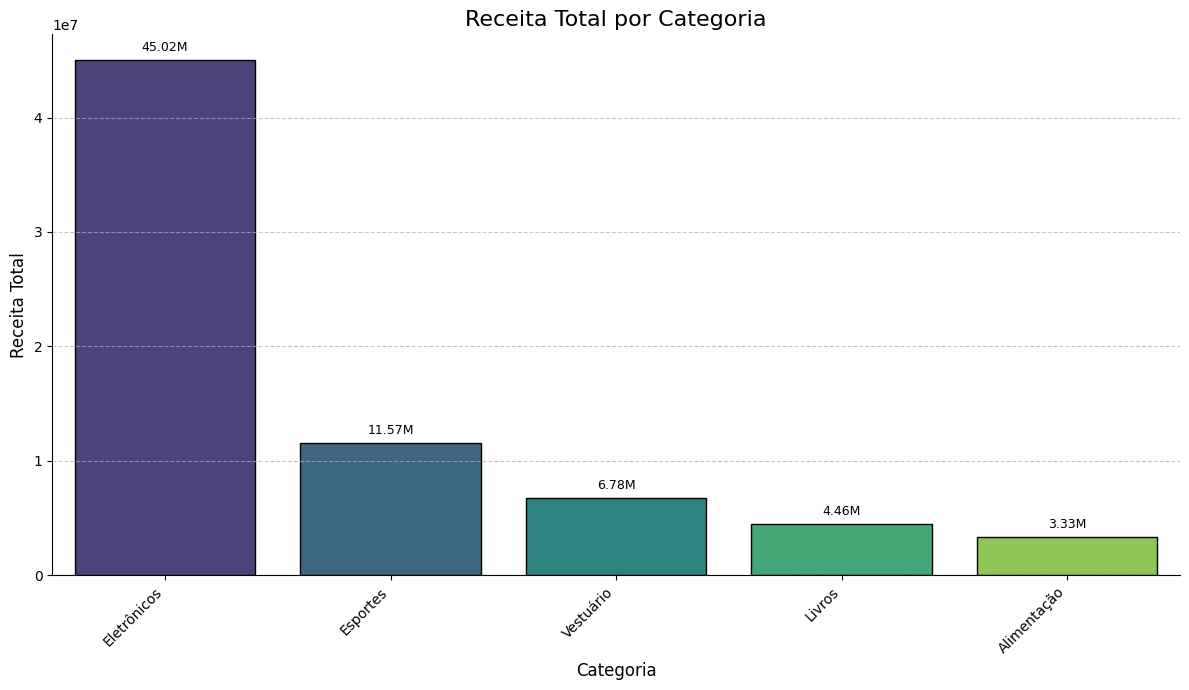

In [27]:
# Calcular a receita total por categoria
receita_por_categoria = df.groupby('categoria')['receita_total'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
ax = sns.barplot(x=receita_por_categoria.index, y=receita_por_categoria.values, palette='viridis', edgecolor='black')

plt.title('Receita Total por Categoria', fontsize=16)
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Receita Total', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
sns.despine(left=False, bottom=False)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    ax.annotate(f'{p.get_height()/1000000:.2f}M',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9),
                textcoords='offset points', fontsize=9, color='black')

plt.tight_layout()
plt.show()

Este gráfico de barras mostra a receita total gerada por cada categoria de produto. Observa-se que 'Eletrônicos' é a categoria que mais contribui para a receita total, seguida por 'Esportes' e 'Vestuário'.

### Gráfico de Linha

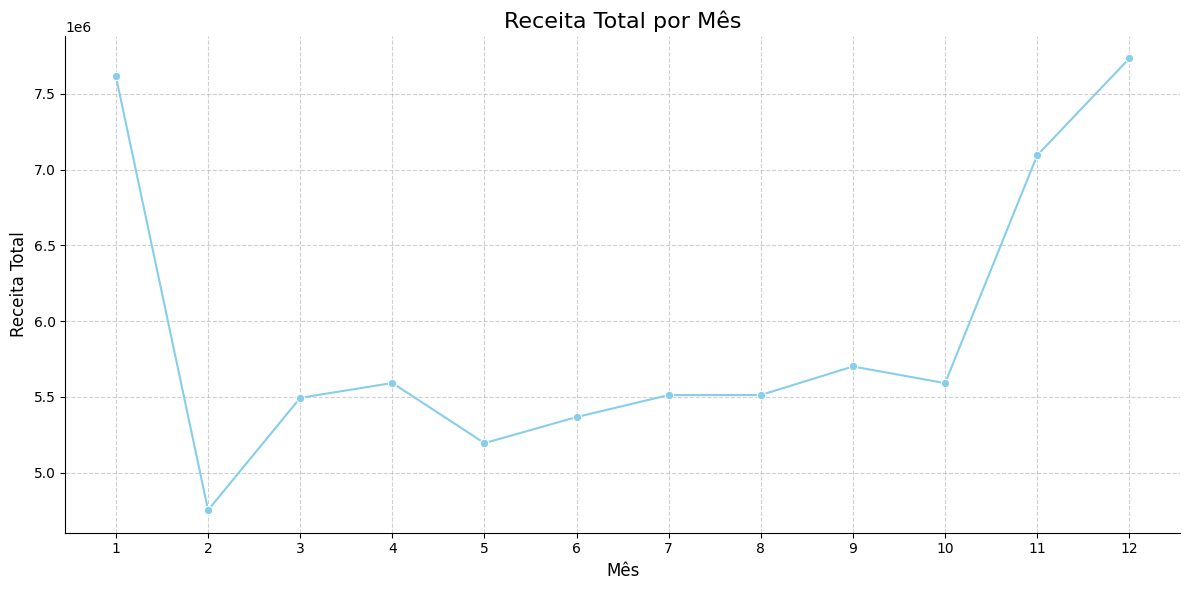

In [23]:
# Agrupar a receita total por mês
receita_por_mes = df.groupby('mes')['receita_total'].sum()

# Criar o gráfico de linha
plt.figure(figsize=(12, 6))
sns.lineplot(x=receita_por_mes.index, y=receita_por_mes.values, marker='o', color='skyblue')

plt.title('Receita Total por Mês', fontsize=16)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Receita Total', fontsize=12)
plt.xticks(receita_por_mes.index, rotation=0) # Exibir todos os meses no eixo x
plt.grid(True, linestyle='--', alpha=0.6)
sns.despine()

plt.tight_layout()
plt.show()

Este gráfico de linha ilustra a receita total por mês ao longo do ano. Podemos observar tendências sazonais, com picos de receita em determinados meses (por exemplo, Janeiro, Novembro e Dezembro) e quedas em outros.

### Gráfico de dispersão

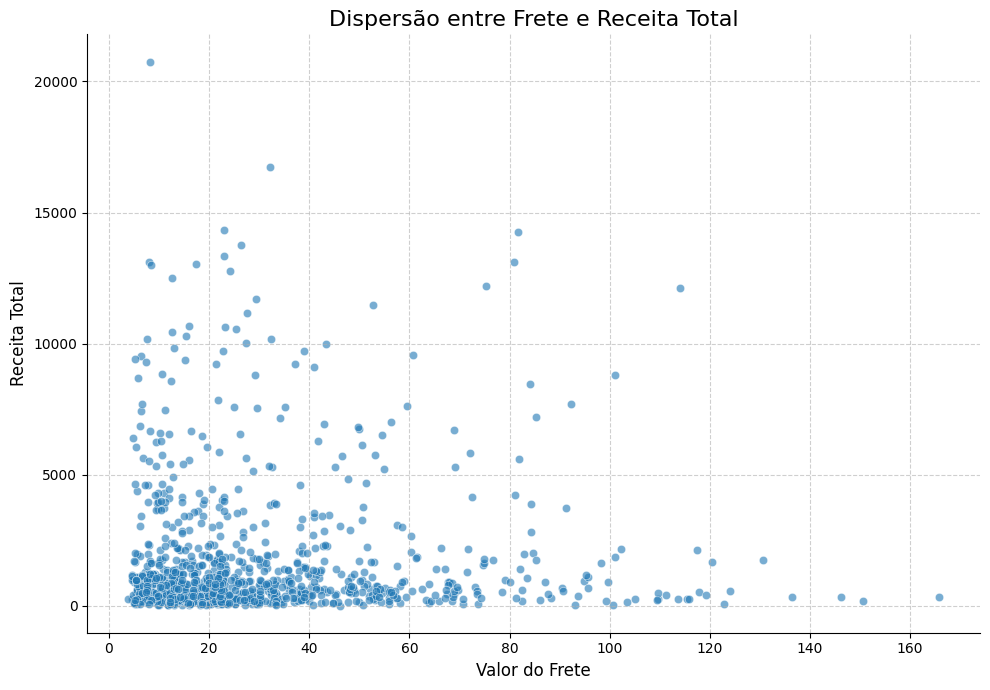

In [29]:
# Amostrar os dados
df_sample = df.sample(n=1000, random_state=42)

# Criar o gráfico de dispersão
plt.figure(figsize=(10, 7))
sns.scatterplot(x='frete', y='receita_total', data=df_sample, alpha=0.6)

plt.title('Dispersão entre Frete e Receita Total', fontsize=16)
plt.xlabel('Valor do Frete', fontsize=12)
plt.ylabel('Receita Total', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
sns.despine()

plt.tight_layout()
plt.show()

Este gráfico de dispersão exibe a relação entre o valor do frete e a receita total. Ele ajuda a identificar se há alguma correlação aparente entre o custo do frete e o valor total das vendas, podendo indicar se fretes mais altos estão associados a vendas de maior ou menor valor (menor nesse caso).

### Mapa de calor

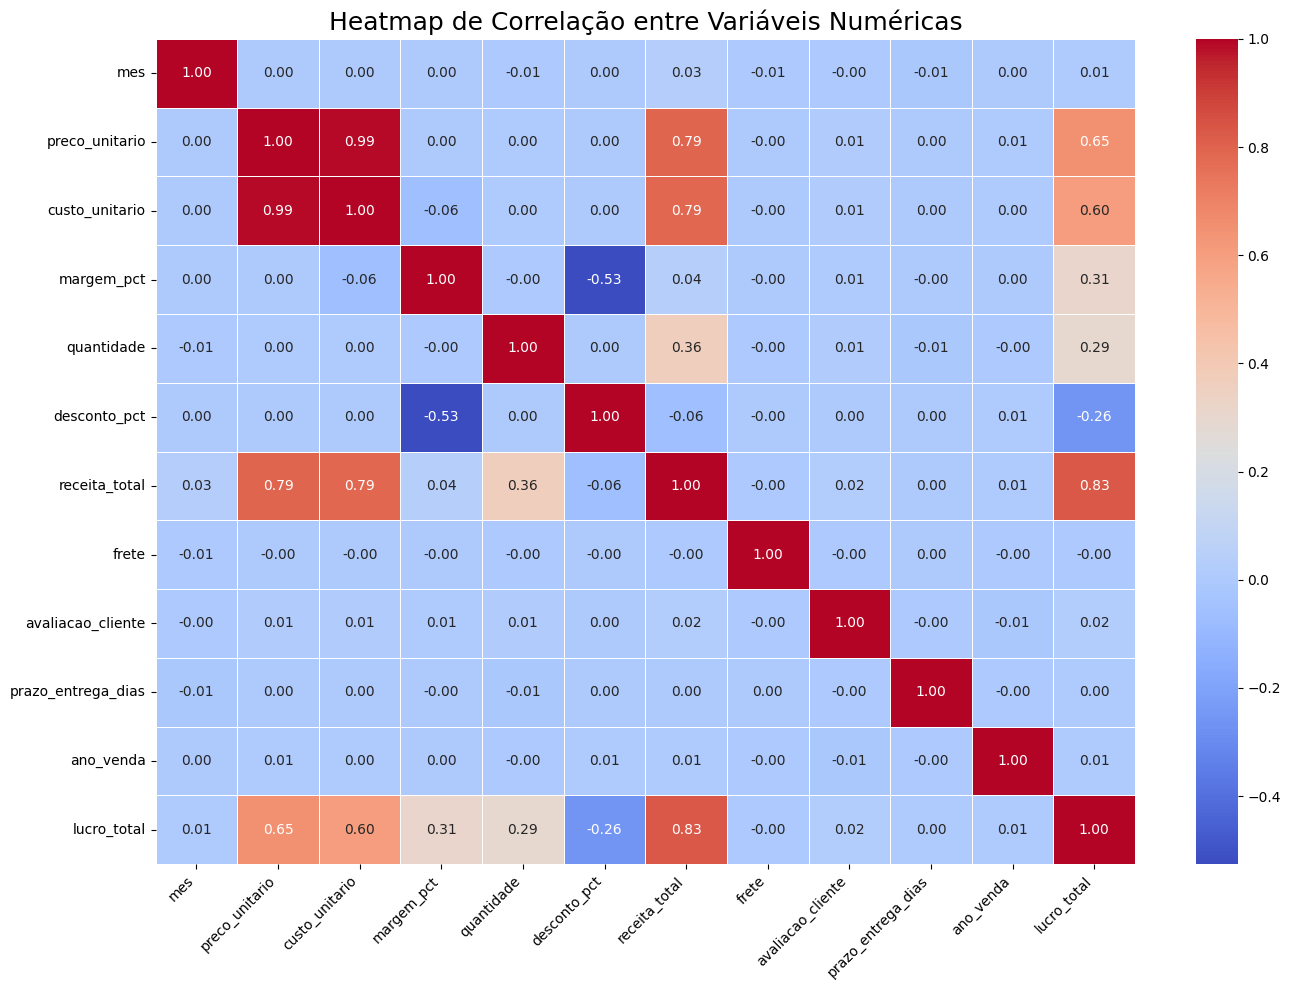

In [30]:
# Selecionar apenas as colunas numéricas para o cálculo da correlação
colunas_numericas = df.select_dtypes(include=['number']).columns

# Calcular a matriz de correlação
matriz_correlacao = df[colunas_numericas].corr()

# Criar o heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap de Correlação entre Variáveis Numéricas', fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

Este heatmap de correlação mostra a relação entre as variáveis numéricas do dataset. Valores próximos a 1 (vermelho forte) indicam uma correlação positiva forte, enquanto valores próximos a -1 (azul forte) indicam uma correlação negativa forte. Valores próximos a 0 (cores neutras/azul claras) indicam pouca ou nenhuma correlação. Isso ajuda a identificar quais variáveis se movem juntas, ou em direções opostas.